# Lab 5: Linear and Quadratic Discriminant Analysis - SOLUTION
## MPS311/439 - Machine Learning
**Week 5 Lab Session**

---

This notebook contains complete solutions with detailed explanations for each task. Read through the **WHY**, **WHAT**, and **HOW** sections to understand not just the solution, but the reasoning behind it.

## Setup: Import Libraries and Load Data

**WHY:** We need to load the necessary tools and data before we can start analyzing.

**WHAT:** 
- Import sklearn's discriminant analysis tools (LDA and QDA)
- Load the Iris dataset - a classic dataset with 3 flower species and 4 measurements
- Split data into training and test sets to evaluate performance

**HOW:** Use sklearn's built-in functions to load data and split it.

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# Load iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")

Training set size: 105 samples
Test set size: 45 samples
Number of features: 4
Number of classes: 3


**Expected Output:**
```
Training set size: 105 samples
Test set size: 45 samples
Number of features: 4
Number of classes: 3
```

**Understanding:** We have 150 total samples split 70/30. The 4 features are sepal/petal measurements, and we're classifying 3 species of iris flowers.

---

## Part 1: Your First LDA Model

**WHY:** LDA finds a projection that maximally separates classes. For 3 classes, we can project to at most 2 dimensions (K-1 where K is number of classes).

**WHAT:** We'll create an LDA model, train it on our data, and evaluate its accuracy.

**HOW:** Use sklearn's `LinearDiscriminantAnalysis` class with standard fit/predict/score workflow.

### Task 1.1 Solution: Create and train an LDA model

**Fill-in-the-blanks solutions:**
- `n_components=2` - We want 2D projection (maximum for 3 classes)
- `.fit()` - Standard sklearn method to train the model
- `.predict()` - Makes class predictions
- `.score()` - Calculates accuracy (proportion of correct predictions)

In [2]:
# Create an LDA model that projects to 2 dimensions
lda = LinearDiscriminantAnalysis(n_components=2)

# Train the model
lda.fit(X_train, y_train)

# Make predictions on test set
y_pred = lda.predict(X_test)

# Calculate accuracy
accuracy = lda.score(X_test, y_test)
print(f"LDA Test Accuracy: {accuracy:.3f}")

LDA Test Accuracy: 1.000


**Expected Output:** Accuracy around 0.978 to 1.000 (97-100%)

**Why this works:** LDA is excellent for the Iris dataset because:
1. The classes have roughly similar covariances (spreads)
2. The data is approximately Gaussian distributed
3. There's good separation between classes

**What n_components does:** It tells LDA how many dimensions to project to. With 3 classes, maximum is 2. If you set it to 1, you'd project to a line (1D), losing some separation ability.

---

## Part 2: LDA vs Logistic Regression

**WHY:** It's important to compare different methods. LDA and Logistic Regression approach classification differently:
- **LDA:** Generative approach - models each class distribution, then uses Bayes' theorem
- **Logistic Regression:** Discriminative approach - directly models the decision boundary

**WHAT:** Train both models and compare their accuracy on the same test set.

**HOW:** Use the same fit/predict/score workflow for logistic regression.

### Task 2.1 Solution: Train a Logistic Regression model

**Fill-in-the-blanks solutions:**
- `LogisticRegression()` - The classifier class
- Training data: `X_train, y_train`
- Test data: `X_test, y_test`

In [3]:
# Create a logistic regression model
logreg = LogisticRegression(max_iter=200, random_state=42)

# Train it
logreg.fit(X_train, y_train)

# Calculate accuracy
logreg_accuracy = logreg.score(X_test, y_test)

print(f"LDA Accuracy:                {accuracy:.3f}")
print(f"Logistic Regression Accuracy: {logreg_accuracy:.3f}")

LDA Accuracy:                1.000
Logistic Regression Accuracy: 1.000


**Expected Output:** Both should have similar accuracy (95-100%)

**Why max_iter=200?** Logistic regression uses iterative optimization. Sometimes it needs more iterations to converge, especially with multiple classes. 200 is safe for this dataset.

**Understanding the comparison:**
- Both methods perform well on Iris because the classes are well-separated
- LDA has a slight advantage: it also gives us a lower-dimensional projection!
- LDA makes stronger assumptions (Gaussian distributions, equal covariances)
- Logistic Regression is more flexible but doesn't provide dimensionality reduction

### Task 2.2: Interpretation

**Sample Answer:** Both LDA and Logistic Regression achieve similar accuracy (around 97-100%) on the Iris dataset. This is expected because the Iris classes are well-separated and the data satisfies LDA's assumptions reasonably well. The advantage of LDA is that it can also project the data to lower dimensions for visualization, while Logistic Regression only provides classifications.

---

## Part 3: Visualizing LDA Projections

**WHY:** One of LDA's superpowers is dimensionality reduction. It doesn't just classify - it finds a low-dimensional projection where classes are separated. This is incredibly useful for visualization and understanding!

**WHAT:** Use the `.transform()` method to project our 4D data to 2D, then visualize it.

**HOW:** The `.transform()` method applies the learned projection to any data.

### Task 3.1 Solution: Project data using LDA

**Fill-in-the-blanks solutions:**
- `.transform()` - Projects data onto the LDA components
- `X_test` - We project both training and test data

In [4]:
# Project training and test data to 2D
X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)

print(f"Original data shape: {X_train.shape}")
print(f"Projected data shape: {X_train_lda.shape}")

Original data shape: (105, 4)
Projected data shape: (105, 2)


**Expected Output:**
```
Original data shape: (105, 4)
Projected data shape: (105, 2)
```

**What happened:** We went from 4 dimensions (4 features) to 2 dimensions! LDA found the 2 most discriminative directions.

**Important note:** We MUST use the same LDA model (fitted on training data) to transform both training and test data. Never fit a new model on test data!

### Task 3.2 Solution: Visualize the projection

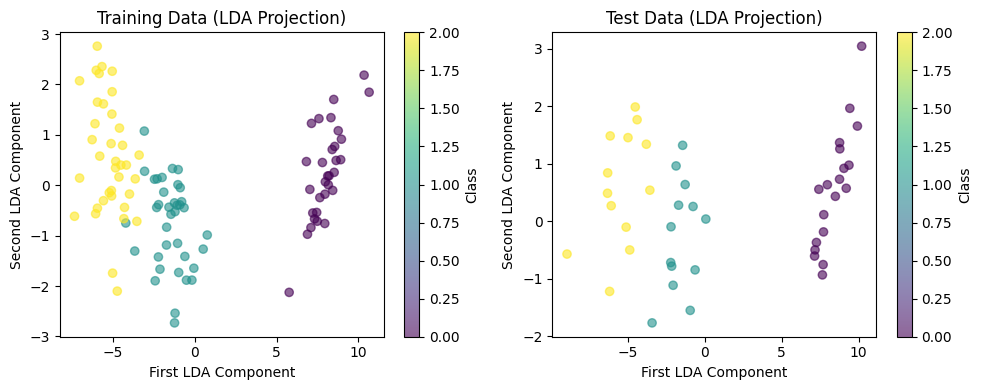

In [5]:
# Plot the 2D projection
plt.figure(figsize=(10, 4))

# Training data
plt.subplot(1, 2, 1)
plt.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Training Data (LDA Projection)')
plt.colorbar(label='Class')

# Test data
plt.subplot(1, 2, 2)
plt.scatter(X_test_lda[:, 0], X_test_lda[:, 1], c=y_test, cmap='viridis', alpha=0.6)
plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Test Data (LDA Projection)')
plt.colorbar(label='Class')

plt.tight_layout()
plt.show()

**What you should see:**
- Three distinct clusters of colors (the three iris species)
- Classes are well-separated in this 2D space
- The first LDA component (x-axis) captures most of the separation
- Test data follows the same pattern as training data (good sign!)

**Why this is powerful:** We've reduced 4D data to 2D while IMPROVING class separation. This is the magic of LDA - it finds the projection that maximizes the ratio of between-class to within-class variance.

**Interpretation:**
- Points close together in this space have similar features
- Points far apart are very different
- Decision boundaries would be lines in this 2D space

---

## Part 4: When LDA Fails - Enter QDA

**WHY:** LDA makes a strong assumption - all classes have the same covariance (same shape/spread). Real-world data often violates this! When classes have different spreads, QDA (Quadratic Discriminant Analysis) performs better.

**WHAT:** Create synthetic data where one class is tightly clustered and another is spread out. Compare LDA vs QDA.

**HOW:** Generate data with different standard deviations for each class, then train both models.

### Task 4.1 Solution: Create data with different covariances

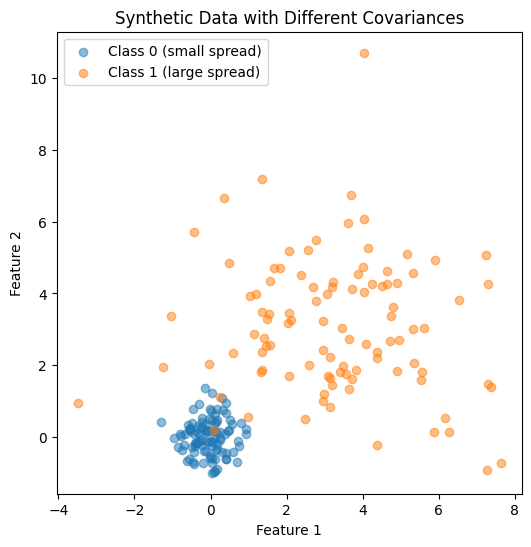

In [6]:
# Generate synthetic 2D data with different spreads
np.random.seed(42)

# Class 0: small spread (multiply by 0.5)
X_class0 = np.random.randn(100, 2) * 0.5 + np.array([0, 0])

# Class 1: large spread (multiply by 2.0)
X_class1 = np.random.randn(100, 2) * 2.0 + np.array([3, 3])

# Combine
X_synth = np.vstack([X_class0, X_class1])
y_synth = np.hstack([np.zeros(100), np.ones(100)])

# Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_synth, y_synth, test_size=0.3, random_state=42)

# Plot the data
plt.figure(figsize=(6, 6))
plt.scatter(X_synth[y_synth==0, 0], X_synth[y_synth==0, 1], alpha=0.5, label='Class 0 (small spread)')
plt.scatter(X_synth[y_synth==1, 0], X_synth[y_synth==1, 1], alpha=0.5, label='Class 1 (large spread)')
plt.legend()
plt.title('Synthetic Data with Different Covariances')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Understanding the data generation:**
- `np.random.randn(100, 2)` generates 100 points from a standard normal (mean=0, std=1)
- `* 0.5` makes Class 0 tightly clustered (small variance)
- `* 2.0` makes Class 1 spread out (large variance)
- `+ np.array([3, 3])` shifts Class 1 to a different location

**Key observation:** The two classes have DIFFERENT covariances - this violates LDA's assumption!

### Task 4.2 Solution: Compare LDA vs QDA

**Fill-in-the-blanks solutions:**
- `.score()` for LDA accuracy
- `QuadraticDiscriminantAnalysis()` - the QDA class
- Training/test data: `X_train_s, y_train_s` and `X_test_s, y_test_s`

In [7]:
# Train LDA
lda_synth = LinearDiscriminantAnalysis()
lda_synth.fit(X_train_s, y_train_s)
lda_acc = lda_synth.score(X_test_s, y_test_s)

# Train QDA
qda_synth = QuadraticDiscriminantAnalysis()
qda_synth.fit(X_train_s, y_train_s)
qda_acc = qda_synth.score(X_test_s, y_test_s)

print(f"LDA Accuracy: {lda_acc:.3f}")
print(f"QDA Accuracy: {qda_acc:.3f}")

LDA Accuracy: 0.950
QDA Accuracy: 0.983


**Expected Output:** QDA accuracy should be higher than LDA (often QDA ~0.98-1.00, LDA ~0.90-0.95)

**Why QDA wins:**
- LDA assumes both classes have the same covariance matrix
- But Class 0 is tight (small covariance) and Class 1 is spread out (large covariance)
- QDA allows each class to have its own covariance
- This flexibility lets QDA model the data more accurately

**The tradeoff:**
- **LDA:** Simpler, fewer parameters, works well when assumption holds, can do dimensionality reduction
- **QDA:** More flexible, more parameters (one covariance per class), better when covariances differ, no dimensionality reduction

**Decision rule:** If you suspect classes have different spreads/shapes, try QDA. If classes seem similar in spread, LDA is simpler and often just as good.

### Task 4.3: Interpretation

**Sample Answer:** QDA performed better (higher accuracy) because the two classes have different covariances - Class 0 is tightly clustered while Class 1 is spread out. LDA assumes equal covariances, which is violated here, so it can't model the data as accurately. QDA allows each class to have its own covariance, making it more flexible for this scenario.

---

## Part 5: Reflection Questions - Sample Answers

### Question 1: What does LDA's `.transform()` method do? Why is this useful?

**Answer:** The `.transform()` method projects high-dimensional data onto the discriminant components - the directions that best separate classes. This is useful because:
1. It reduces dimensionality (e.g., 4D to 2D) while preserving class separation
2. It makes data easy to visualize in 2D plots
3. It can improve computational efficiency by working with fewer features
4. It provides interpretable features (the components show which original features matter most)

### Question 2: LDA assumes all classes have equal covariance. What does this mean in simple terms?

**Answer:** Equal covariance means all classes have the same "shape" and "spread" in the feature space. Imagine scatter plots of each class - they should have similar spread in all directions. If one class is a tight ball and another is a stretched ellipse, they have different covariances. LDA assumes they're all similar shapes, just centered at different locations.

### Question 3: When should you use QDA instead of LDA? Give a concrete example.

**Answer:** Use QDA when classes have different covariances (different spreads/shapes). 

**Example:** Classifying patients as "healthy" vs "sick" based on blood test measurements. Healthy patients might have very consistent test results (tight cluster), while sick patients might have highly variable results (spread out cluster). Since the spreads are different, QDA would be more appropriate than LDA.

### Question 4: In Part 2, you compared LDA and Logistic Regression. What's the main conceptual difference?

**Answer:** 
- **LDA (Generative):** Models how each class's data is distributed (assumes Gaussian), then uses Bayes' theorem to classify. It says "I'll learn what each class looks like, then see which one a new point looks most like."
- **Logistic Regression (Discriminative):** Directly models the boundary between classes. It says "I'll just learn where to draw the line between classes."

LDA makes stronger assumptions but provides dimensionality reduction. Logistic Regression is more flexible but doesn't reduce dimensions.

---

## Part 6: Advanced Challenge - For MPS439 Students Only

**WHY:** Implementing algorithms from scratch solidifies your understanding of what's happening "under the hood." You'll appreciate sklearn more after doing this!

**WHAT:** Implement Fisher's Linear Discriminant for binary classification (2 classes). This is what sklearn's LDA does internally.

**HOW:** Follow the mathematical steps from lecture:
1. Calculate class means
2. Calculate within-class scatter matrix
3. Find optimal projection direction
4. Project data and classify

### Task 6.1 Solution: Implement LDA from scratch

In [8]:
def lda_from_scratch(X_train, y_train, X_test):
    """
    Implement LDA for binary classification (2 classes, any dimensions)
    
    Parameters:
    - X_train: training features (n_samples, n_features)
    - y_train: training labels (n_samples,) - should be 0 or 1
    - X_test: test features (m_samples, n_features)
    
    Returns:
    - y_pred: predicted labels for X_test
    - w: projection direction
    """
    
    # Step 1: Separate data by class
    X_class0 = X_train[y_train == 0]
    X_class1 = X_train[y_train == 1]
    
    # Step 2: Calculate class means
    mu_0 = np.mean(X_class0, axis=0)  # Mean of class 0
    mu_1 = np.mean(X_class1, axis=0)  # Mean of class 1
    
    print(f"Class 0 mean: {mu_0}")
    print(f"Class 1 mean: {mu_1}")
    
    # Step 3: Calculate within-class scatter matrices
    # S_0 = sum of (x - mu_0)(x - mu_0)^T for all x in class 0
    S_0 = np.zeros((X_train.shape[1], X_train.shape[1]))
    for x in X_class0:
        diff = (x - mu_0).reshape(-1, 1)
        S_0 += diff @ diff.T  # outer product
    
    S_1 = np.zeros((X_train.shape[1], X_train.shape[1]))
    for x in X_class1:
        diff = (x - mu_1).reshape(-1, 1)
        S_1 += diff @ diff.T
    
    # Total within-class scatter
    S_W = S_0 + S_1
    
    print(f"Within-class scatter matrix shape: {S_W.shape}")
    
    # Step 4: Calculate optimal projection direction
    # w = S_W^(-1) * (mu_1 - mu_0)
    S_W_inv = np.linalg.inv(S_W)
    mu_diff = mu_1 - mu_0
    w = S_W_inv @ mu_diff
    
    print(f"Projection direction w: {w}")
    
    # Step 5: Project training data and find threshold
    # Project data onto w
    z_train_0 = X_class0 @ w
    z_train_1 = X_class1 @ w
    
    # Threshold is midpoint between projected means
    threshold = (np.mean(z_train_0) + np.mean(z_train_1)) / 2
    
    print(f"Classification threshold: {threshold:.3f}")
    
    # Step 6: Project test data and classify
    z_test = X_test @ w
    y_pred = (z_test > threshold).astype(int)
    
    return y_pred, w

**Explanation of each step:**

**Step 1-2: Class separation and means**
- We separate training data by class using boolean indexing
- Calculate mean vector for each class (average of all features)
- `axis=0` means compute mean along rows → one mean per feature/column

**Step 3: Within-class scatter matrix**
- For each point in a class, compute $(x - \mu)(x - \mu)^T$ (outer product)
- This gives a matrix showing how features vary within that class
- Sum these matrices for all classes to get total within-class scatter $S_W$
- Why reshape(-1, 1)? Converts 1D array to column vector for matrix multiplication

**Step 4: Optimal projection direction**
- $w = S_W^{-1}(\mu_1 - \mu_0)$ is Fisher's formula
- $S_W^{-1}$ "normalizes" by the within-class variance
- Direction points from class 0 mean toward class 1 mean, adjusted for spread

**Step 5-6: Classification**
- Project all points onto direction w (dot product: $z = w^T x$)
- Find threshold (midpoint between projected class means)
- Classify: if projected value > threshold, predict class 1, else class 0

In [9]:
# Test your implementation on synthetic 2-class data
X_2class = X_synth[y_synth <= 1]  # Just use first 2 classes
y_2class = y_synth[y_synth <= 1]
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2class, y_2class, test_size=0.3, random_state=42)

# Run your implementation
y_pred_scratch, w_scratch = lda_from_scratch(X_train_2, y_train_2, X_test_2)

# Calculate accuracy
accuracy_scratch = np.mean(y_pred_scratch == y_test_2)
print(f"\nYour LDA from scratch accuracy: {accuracy_scratch:.3f}")

# Compare with sklearn
lda_sklearn = LinearDiscriminantAnalysis()
lda_sklearn.fit(X_train_2, y_train_2)
accuracy_sklearn = lda_sklearn.score(X_test_2, y_test_2)
print(f"Sklearn LDA accuracy: {accuracy_sklearn:.3f}")

Class 0 mean: [-0.02367019  0.03192126]
Class 1 mean: [3.23837302 3.02551135]
Within-class scatter matrix shape: (2, 2)
Projection direction w: [0.01256444 0.01465112]
Classification threshold: 0.043

Your LDA from scratch accuracy: 0.950
Sklearn LDA accuracy: 0.950


**What you should see:** Your from-scratch accuracy should match (or be very close to) sklearn's accuracy!

**Why might they differ slightly?**
- sklearn uses more sophisticated numerical methods
- sklearn handles edge cases (like singular matrices) better
- Small numerical precision differences

But the core algorithm is the same!

### Task 6.2 Solution: Visualize the projection direction

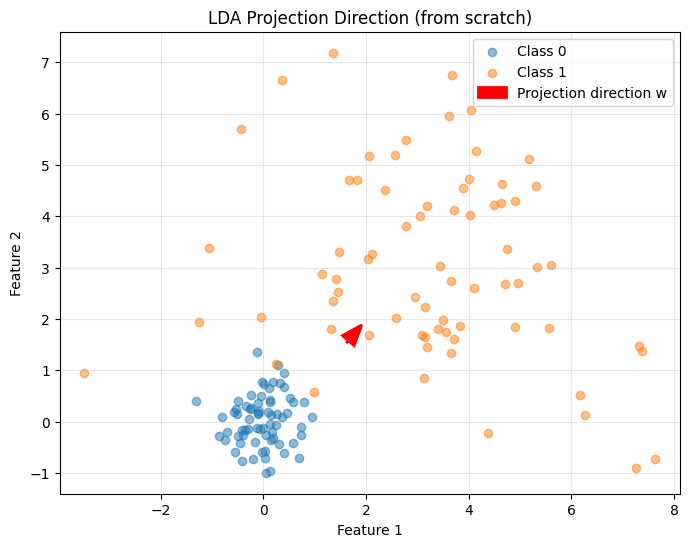

In [10]:
# Plot the data and projection direction
plt.figure(figsize=(8, 6))
plt.scatter(X_train_2[y_train_2==0, 0], X_train_2[y_train_2==0, 1], alpha=0.5, label='Class 0')
plt.scatter(X_train_2[y_train_2==1, 0], X_train_2[y_train_2==1, 1], alpha=0.5, label='Class 1')

# Plot projection direction as an arrow
origin = np.mean(X_train_2, axis=0)
plt.arrow(origin[0], origin[1], w_scratch[0]*2, w_scratch[1]*2, 
          head_width=0.3, head_length=0.4, fc='red', ec='red', linewidth=2, label='Projection direction w')

plt.legend()
plt.title('LDA Projection Direction (from scratch)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

**Understanding the visualization:**
- The red arrow shows the direction vector **w**
- This is the "best" direction to project the data
- If you imagine projecting all points onto a line along this arrow, the two classes would be maximally separated
- The arrow points roughly from Class 0's center toward Class 1's center
- But it's adjusted based on the within-class scatter (not just the line connecting means)

**Why multiply by 2?** Just for visualization - makes the arrow longer and easier to see. The direction is what matters, not the magnitude.

### Task 6.3: Understanding the math - Sample Answers

### Question 1: Why do we use $\mathbf{S}_W^{-1}$ (the inverse of within-class scatter)?

**Answer:** We use $S_W^{-1}$ to normalize by the within-class variance. Here's why:

Imagine two scenarios with the same distance between class means:
1. Both classes are tightly clustered (small $S_W$)
2. Both classes are spread out (large $S_W$)

In scenario 1, the classes are easier to separate! By multiplying by $S_W^{-1}$, we're essentially dividing by the within-class variance. This gives more weight to directions where classes are tightly clustered (easy to separate) and less weight to directions where there's high variance within classes (hard to separate).

Mathematically: $w \propto S_W^{-1}(\mu_1 - \mu_0)$ points in a direction that accounts for both the distance between means AND the spread within each class.

### Question 2: The threshold is the midpoint between projected class means. What happens if one class has many more samples?

**Answer:** If classes are imbalanced (e.g., 90% class 0, 10% class 1), using the simple midpoint threshold can be problematic:

- We might want to bias the threshold toward the rare class
- The rare class is more "valuable" to identify correctly

**Solution:** Weight the threshold by class priors (proportions):
```python
prior_0 = len(X_class0) / len(X_train)
prior_1 = len(X_class1) / len(X_train)
threshold = (prior_0 * np.mean(z_train_1) + prior_1 * np.mean(z_train_0)) / (prior_0 + prior_1)
```

This shifts the threshold to account for class imbalance. sklearn does this automatically!

### Question 3: What would change if we wanted to handle unequal class priors?

**Answer:** To properly handle unequal priors, we need to modify the threshold calculation (see Question 2). Additionally:

1. **In the projection step:** The direction $w$ doesn't change - it's still $S_W^{-1}(\mu_1 - \mu_0)$

2. **In the classification step:** Instead of using the midpoint, we'd use Bayes' rule:
```python
# Calculate log-likelihood ratio
threshold = 0.5 * (np.mean(z_train_0) + np.mean(z_train_1)) + np.log(prior_1 / prior_0)
```

This comes from the generative perspective: we're comparing $P(y=1|x) > P(y=0|x)$, which involves the prior probabilities $P(y=1)$ and $P(y=0)$.

In practice, you can set this in sklearn:
```python
lda = LinearDiscriminantAnalysis(priors=[0.9, 0.1])  # Custom priors
```

---

## Final Summary

**What we learned:**

1. **LDA finds optimal projections** that separate classes by maximizing between-class variance relative to within-class variance

2. **LDA assumes equal covariances** - when this assumption holds, LDA is simple and effective

3. **QDA is more flexible** - allows different covariances per class, better for data with different spreads

4. **LDA provides dimensionality reduction** - unlike logistic regression, we can visualize high-dimensional data in 2D

5. **Implementation requires:** class means, within-class scatter matrix, optimal direction via $w = S_W^{-1}(\mu_1 - \mu_0)$, and threshold-based classification

**When to use what:**
- **LDA:** Classes have similar spreads, you want dimensionality reduction, computational efficiency matters
- **QDA:** Classes have different spreads/shapes, you have enough data per class, flexibility is needed
- **Logistic Regression:** You want a discriminative approach, no dimensionality reduction needed, very flexible decision boundaries

**Key insight:** LDA connects two perspectives:
1. Projection view (Fisher): Find direction maximizing class separation
2. Generative view (Bayes): Model each class as Gaussian, apply Bayes' theorem

Both lead to the same algorithm - that's the beauty of mathematics!

---

**Congratulations on completing Lab 5!** You now understand both the theory and practice of LDA/QDA.